#Exercise Generalised Linear Regression

**Authors:** Sek Huen Leung, Kadri Kalamäe

**Date:** 03.09.2026

In [74]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import gdown

gdown.download(
    id="1OrcbfMsqtZn-3S0ed3TGJnFT-2rVTv3v",
    output="bird_count.csv",
    quiet=True
)

np.random.seed(123) # setting the seed in order to get reproducible results

In [75]:
# Poisson regression log likelihood
def poi_log_l(beta_, x_, y_):
  # minus sign added in front because later we minimize the function
  # minimizing -log L is equivalent to maximizing log L
  # -log(y!) term is dropped since it doesn't depend on beta and so doesn't affect the argmax
  return -np.sum(-np.exp(beta_[0]+beta_[1]*x_)+y_*(beta_[0]+beta_[1]*x_))

# Poisson regression
def poi_reg(y_, x_):
  x0 = np.array([0.,0.1]) # initial values for beta
  res = minimize(poi_log_l,x0,args=(x_, y_))
  beta_ = res.x
  return beta_

# Poisson prediction
def poi_pred(x_, beta_):
  mu_ = np.exp(beta_[0]+ beta_[1]*x_)
  y_hat = poisson.rvs(mu_)
  return y_hat

In [76]:
# Load data file
data = pd.read_csv("bird_count.csv")

# Response
y_ = data["count"].to_numpy()

# Input variable
x_ = data["yr"].to_numpy()
# years from 1999 to 2012
# large predictor values cause exp() overflow
# this is why we scale the year variable
x_ = x_ - 1999

In [77]:
# Parameters estimation
beta_ = poi_reg(y_, x_)
print("Estimated parameters:")
print(beta_)

Estimated parameters:
[ 2.32533193 -0.03244318]


In [78]:
# samples
input = np.arange(1999, 2013)
input = input - 1999

samples = []

for i in range(3):

    pred = poi_pred(input, beta_)

    sample_i = pd.DataFrame({
        "sample": i + 1,
        "year": input + 1999,
        "count": pred
    })

    samples.append(sample_i)

sample_data = pd.concat(samples, ignore_index=True)

sample_data.to_csv(
    "bird_count_samples.csv",
    index=False
)

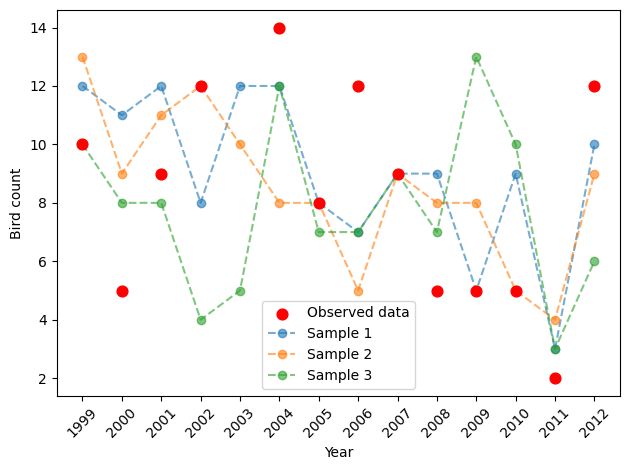

In [79]:
# Plot
plt.figure()
# Original observations
plt.scatter(
    x_ + 1999,
    y_,
    label="Observed data",
    color='red',
    s=60,
    zorder=5
)


# Plot the three simulated samples
for i in range(1, 4):

    temp = sample_data[sample_data["sample"] == i]

    plt.plot(
        temp["year"],
        temp["count"],
        marker="o",
        linestyle="--",
        alpha=0.6,
        label=f"Sample {i}"
    )


plt.xlabel("Year")
plt.ylabel("Bird count")
plt.xticks(input + 1999, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()